In [6]:
import sys
sys.path.append("../utils/")
import utils as ut
import plot_config as pco
import xarray as xr
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
import numpy as np
import string
from tqdm import tqdm

# Functions

In [7]:
def plot_p_variable(typ,ax,percentile,scenario,i):
    """
    Plots all events above a certain percentile either as day of year or hour of day (specified through typ) for a given scenario and for a figure ax and color i
    """
    if typ == "doy":
        doy = percentile.groupby("time.dayofyear").mean()
        to_plot = ut.get_smoothed_doy(doy,21) # smooth with a 21 day rolling mean
        ax.fill_between(to_plot.dayofyear,0,to_plot,alpha=0.3,color=pco.colors[1-i],label=ut.scen_config_dict[scenario])

    elif typ == "hod":
        to_plot = percentile.groupby("time.hour").mean()
        ax.fill_between(to_plot.hour,0,to_plot,alpha=0.3,color=pco.colors[1-i],label=ut.scen_config_dict[scenario])
    ax.set_title(f"")
    if typ == "doy":
        ax.set_xticks([60,152,244,335],labels=["Mar","Jun","Sep","Dec"])
    elif typ == "hod": 
        ax.set_xlabel("Hour of day")
        ax.set_xticks([3,9,15,21])
    #plot configs
    ax.set_ylabel("")

# Open files

In [3]:
path = "/net/xenon/climphys/lbloin/energy_boost/"
# get net load for different scenarios and assumptions
nl = {}
for scenario in  ut.CESM2_REALIZATION_DICT: 
    nl_scen = {
        "copperplate":xr.open_dataset(f"{path}net_load_hydro_storage_{scenario}.nc").net_load_adjusted,
        "realistic_transmission":xr.open_dataset(f"{path}net_load_transmission_{scenario}.nc").net_load
    }
    nl[scenario] = nl_scen

#list of different scenarios and assumptions
transmission_types = ["copperplate","realistic_transmission"]
capacity_scenarios = nl[scenario]["copperplate"].capacity_scenario.values
heating_scenarios = nl[scenario]["copperplate"].heating_scenario.values
scenario_configs = [["current","current_electrified"],["future","fully_electrified"],["future_wind_x2","current_electrified"]]

In [4]:
# get percentile for all climate model data combined, but separate for each scenario
qu_all_diff_percentile = {}
for percentile in [0.9,0.95,0.99]:
    qu_all = []
    for typ in transmission_types:
        qu_capac = []
        for x,capacity_scenario in enumerate(capacity_scenarios):
            qu_heat = []
            for j,heating_scenario in enumerate(heating_scenarios):
                nl_for_qu = []
                for scenario in nl.keys():
                    nl_for_qu.append(nl[scenario][typ].sel(capacity_scenario=capacity_scenario,heating_scenario=heating_scenario).dropna(dim='time').values)
                qu_heat.append(np.quantile(np.array(nl_for_qu),percentile))
            qu_capac.append(qu_heat)
        qu_all.append(qu_capac)
    qu_all = xr.DataArray(
        qu_all,
        dims=["transmission_type","capacity_scenario","heating_scenario"],
        coords = {"transmission_type":transmission_types,"capacity_scenario":capacity_scenarios,"heating_scenario":heating_scenarios}
    )
    qu_all_diff_percentile[percentile] = qu_all

# Plots

100%|██████████| 3/3 [00:23<00:00,  7.84s/it]


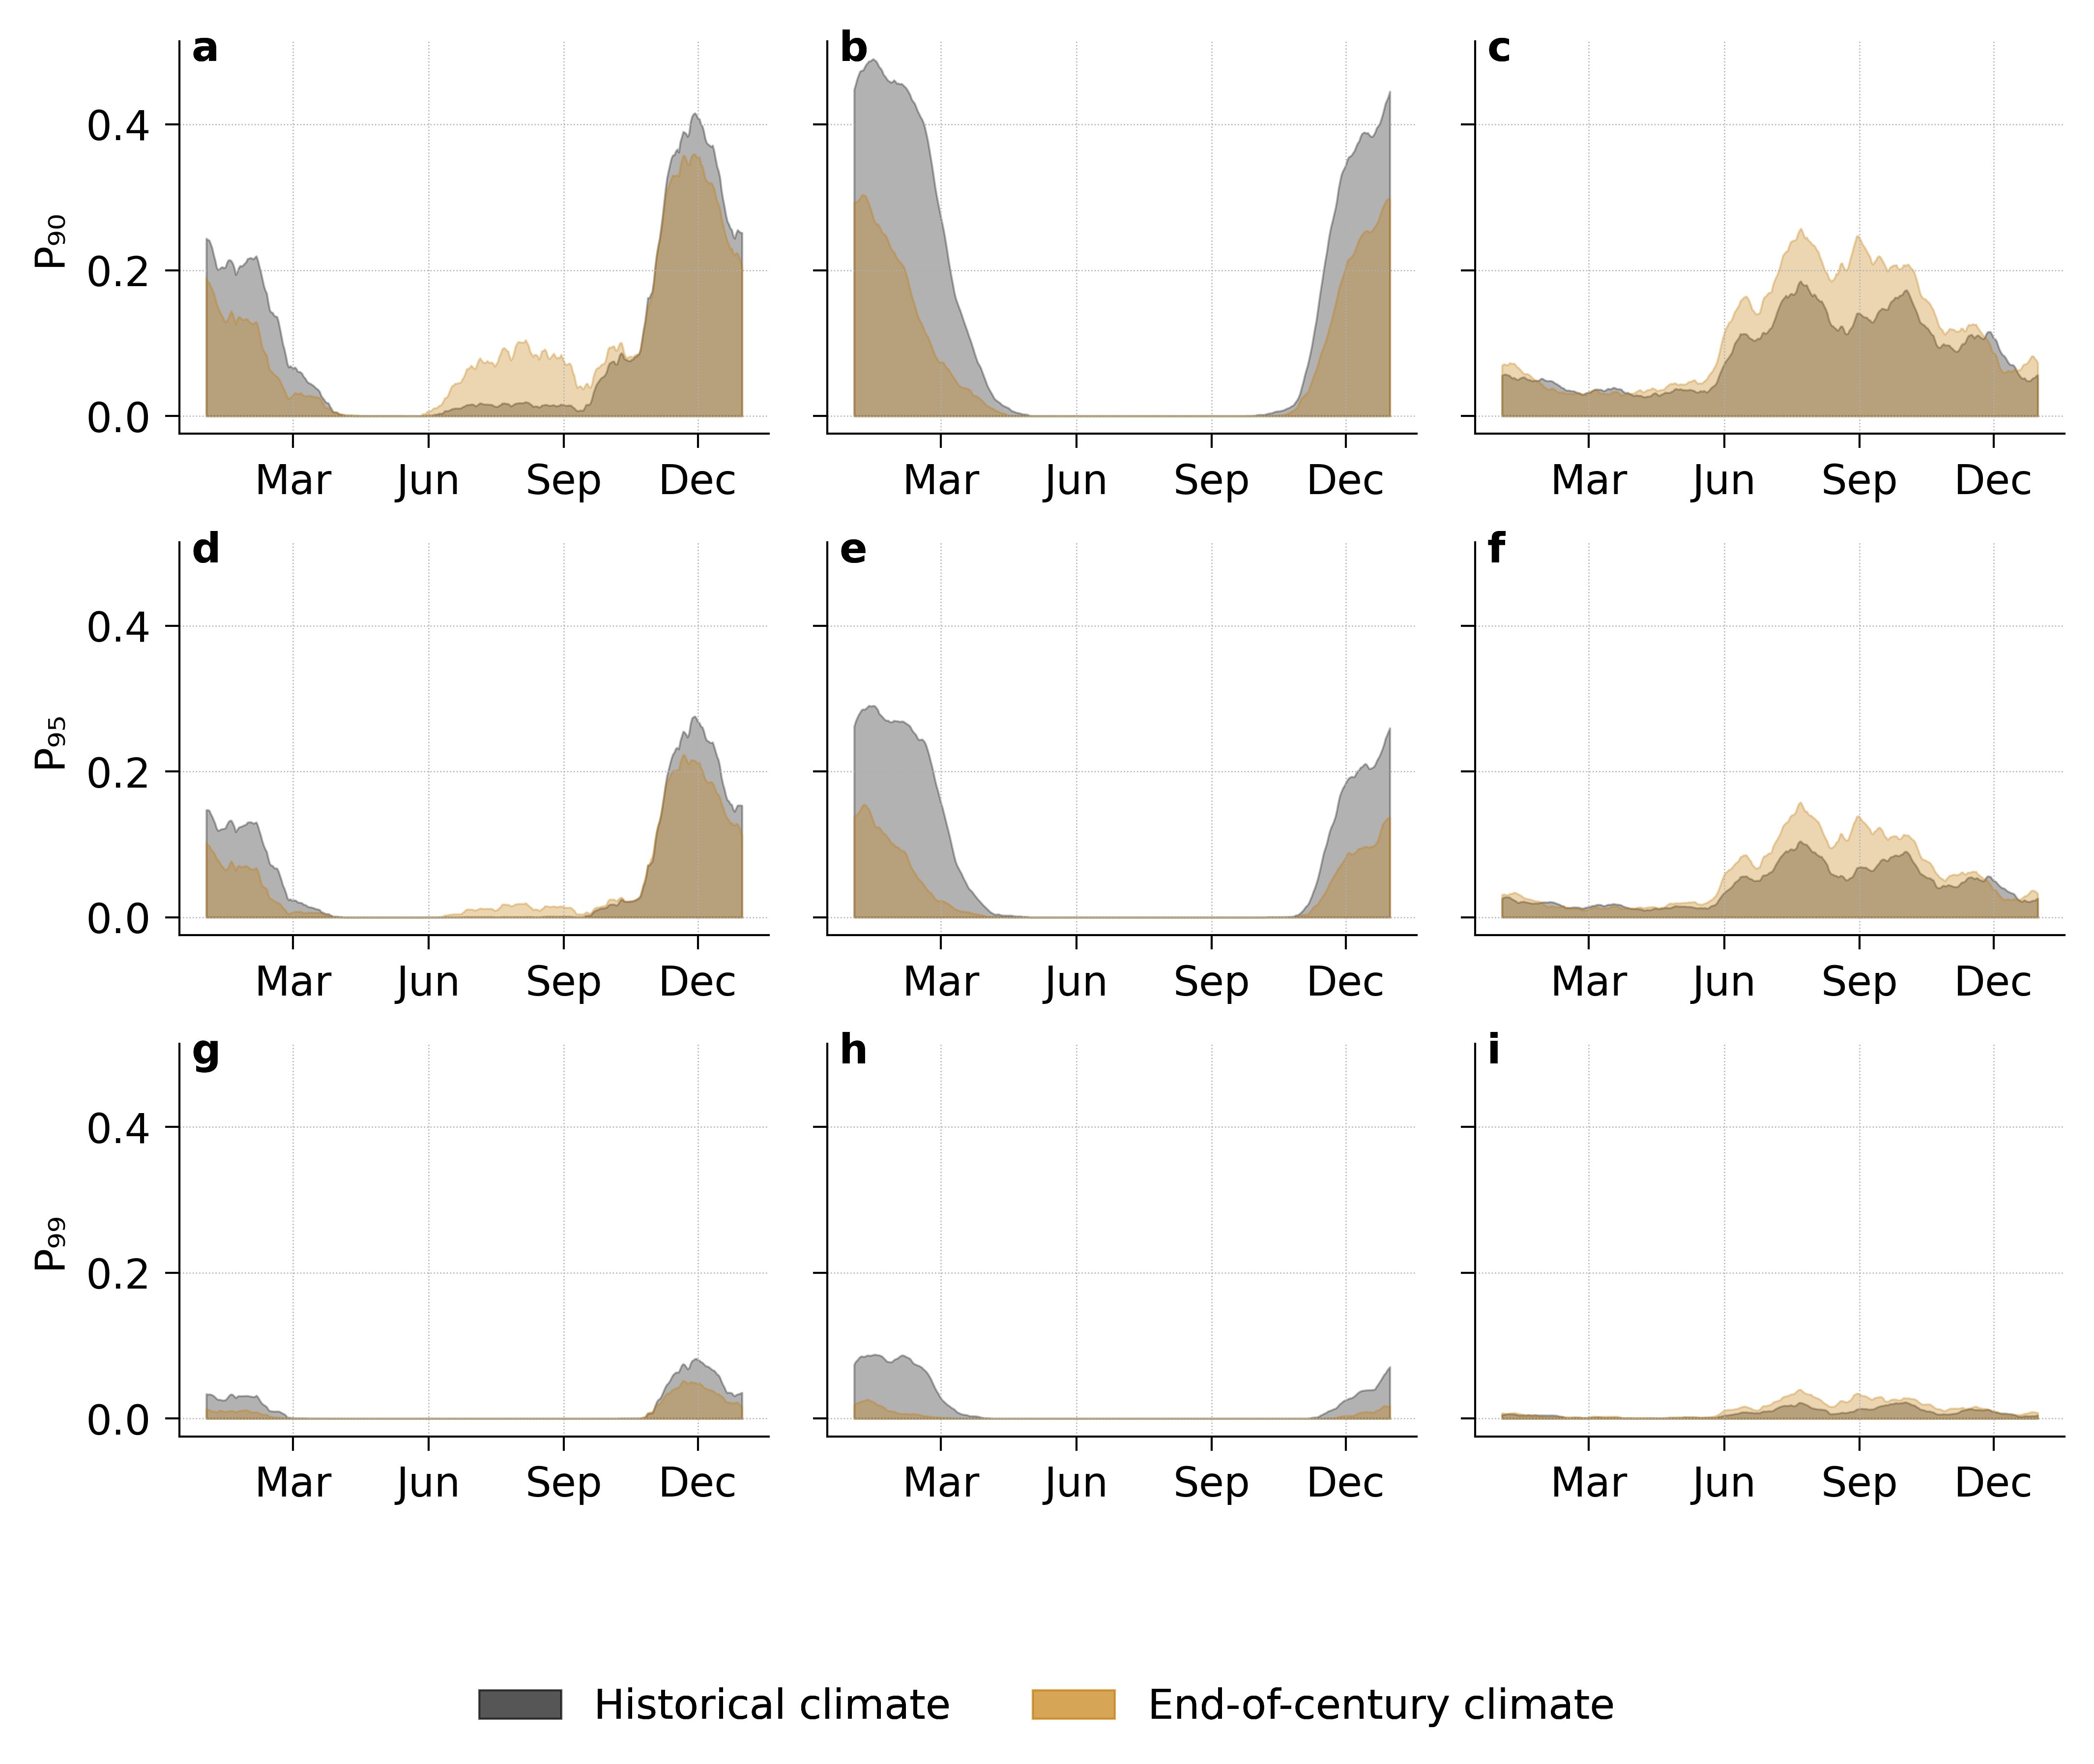

In [9]:
title = ["P\u2089\u2080","P\u2089\u2085","P\u2089\u2089"]
f,ax=plt.subplots(3,3,figsize=(7.2,6),sharey=True)
for p,percentile in enumerate(tqdm([0.9,0.95,0.99])):
    qu_all = qu_all_diff_percentile[percentile]
    # figure 3 from paper
    for j,config in enumerate(scenario_configs):
        for i, scenario in enumerate(nl.keys()): #open hist and SSP370
            # get net load
            net_load = nl[scenario]["realistic_transmission"].sel(capacity_scenario=config[0],heating_scenario=config[1])
            net_load_stacked = net_load.stack(event=("member","time")).dropna(dim="event")
            # percentile to work with
            qu_nl = qu_all.sel(capacity_scenario=config[0],heating_scenario=config[1],transmission_type="realistic_transmission")
            # frequency of events above percentile
            ext = xr.where(net_load_stacked>qu_nl,1,0)
            # dayofyear
            plot_p_variable("doy",ax[p][j],ext,scenario,i)
            #hour of day
            #plot_p_variable("hod",ax[1][j],ext,scenario,i)
            pco.set_grid(ax[p][j])
            ax[p][j].text(0.02,0.95,string.ascii_lowercase[j+p*3],weight="bold",transform=ax[p][j].transAxes)
            ax[p][j].spines['right'].set_visible(False)
            ax[p][j].spines['top'].set_visible(False)
    ax[p][0].set_ylabel(title[p])#f.text(0.01,0.6,title[p],rotation='vertical',verticalalignment='center', horizontalalignment='center',fontsize=12)
    handles, labels = ax[0][0].get_legend_handles_labels()
    f.legend(handles, labels, loc='lower center',ncol=2, frameon=False)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
plt.savefig(f"../../figs_CC_impacts/fig3_percentile_changes.png",bbox_inches ="tight", dpi = 600)